# SBS Selection MLP Inspection

Inspect the v6 Bernoulli selection model for the pilot target $s=1 \equiv$ SExtractor detection.

The current default model uses the **primary-major-axis frame**: `parallel` is the spin-2 shear component aligned with the primary intrinsic ellipticity, while `cross`/`perp` is the 45-degree rotated spin-2 component in that same local frame. Secondary and pair-geometry inputs are gated by `neighbored`, so isolated rows do not carry arbitrary neighbour properties.

Full-catalogue training and heavy gradient checks should remain Slurm workflows. This notebook does lightweight sample inspection and reads the Slurm diagnostic summaries already written under `SBSI/results`.

In [ ]:
# Edit this cell to inspect a different model or catalogue.

SBS_ROOT = "/home/z/Zekang.Zhang/SBSI"
CATALOGUE = "/project/ls-gruen/users/zekang.zhang/lsst_selec_emu/sbs_skycos/sbs_detection_measurement_catalogue_train.feather"
FALLBACK_CATALOGUE = "/project/ls-gruen/users/zekang.zhang/lsst_selec_emu/sbs_skycos_nearest/sbs_detection_measurement_catalogue_train.feather"
MODEL_PATH = "/home/z/Zekang.Zhang/SBSI/models/selection_mlp_detected_v6_primary_frame.pt"
FALLBACK_MODEL_PATH = "/home/z/Zekang.Zhang/SBSI/models/selection_mlp_detected_v5_gated_pair.pt"
TARGET_COLUMN = "detected"

BLEND_RESULTS_DIR = "/home/z/Zekang.Zhang/SBSI/results/selection_blends_v6_primary_frame"
GRADIENT_RESULTS_DIR = "/home/z/Zekang.Zhang/SBSI/results/selection_gradient_study_v6_primary_frame"
INVARIANCE_RESULTS_DIR = "/home/z/Zekang.Zhang/SBSI/results/selection_far_neighbor_invariance_v6_primary_frame"

RUN_LABEL = "SBS selection MLP v6: primary-frame SExtractor detection"
DEVICE = None  # auto-select cuda if available, else cpu

# Interactive controls. Set MAX_READ_BATCHES=None only in a Slurm/notebook job.
MAX_ROWS = 300_000
MAX_READ_BATCHES = 300
RANDOM_STATE = 911
BATCH_SIZE = 65_536
BLEND_RADII = (2.0, 3.0)
BLEND_GRADIENT_ROWS = 20_000
PAIR_DISTANCE_GRADIENT_ROWS = 50_000
NO_NEIGHBOR_GRADIENT_ROWS = 30_000
GRADIENT_BATCH_SIZE = 8_192
PROGRESS_EVERY = 100

RESCALE = dict(pixel_rms=0.312, pixel_size=0.2, zero_mag=30.0, psf_fwhm=0.73, moffat_beta=2.224)

In [ ]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

SBS_ROOT = Path(SBS_ROOT).expanduser().resolve()
if str(SBS_ROOT) not in sys.path:
    sys.path.insert(0, str(SBS_ROOT))
DEVICE = DEVICE or ("cuda" if torch.cuda.is_available() else "cpu")

from sbs_shear.coordinates import add_shear_aligned_gradients
from sbs_shear.preprocessing import DEFAULT_SELECTION_CUTS, SHEAR_FEATURES, raw_columns_for_selection_features, rescale, source_select_selection
from sbs_shear.selection_model import load_selection_model

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "figure.dpi": 120,
})
cbPalette = ("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7")


def model_artifact(path, suffix):
    path = Path(path).expanduser().resolve()
    return path.with_name(path.stem + suffix)


def load_result_csv(path):
    path = Path(path).expanduser().resolve()
    if not path.exists():
        print(f"Missing result file: {path}")
        return None
    return pd.read_csv(path)


def raw_columns_for_features(features, available_columns=None):
    columns = raw_columns_for_selection_features(features, available_columns=available_columns)
    columns.update([TARGET_COLUMN, "case", "shear_case", "polarization_angle"])
    return columns


def add_legacy_missing_shear(frame, features):
    frame = frame.copy()
    for name in features:
        if name not in frame.columns and name in SHEAR_FEATURES:
            frame[name] = 0.0
    missing = [name for name in features if name not in frame.columns]
    if missing:
        raise KeyError(f"Missing required feature columns: {missing}")
    return frame


def append_to_priority_sample(reservoir, batch, max_rows, rng):
    if max_rows is None or max_rows <= 0:
        return pd.concat([reservoir, batch], ignore_index=True) if reservoir is not None else batch
    batch = batch.copy()
    batch["__sample_key"] = rng.random(len(batch))
    reservoir = pd.concat([reservoir, batch], ignore_index=True) if reservoir is not None else batch
    if len(reservoir) > 2 * max_rows:
        reservoir = reservoir.nlargest(max_rows, "__sample_key").reset_index(drop=True)
    return reservoir


def finalize_priority_sample(reservoir, max_rows):
    if reservoir is None:
        raise RuntimeError("No rows were loaded from the catalogue")
    if max_rows is not None and max_rows > 0 and len(reservoir) > max_rows:
        reservoir = reservoir.nlargest(max_rows, "__sample_key").reset_index(drop=True)
    if "__sample_key" in reservoir.columns:
        reservoir = reservoir.drop(columns="__sample_key")
    return reservoir.reset_index(drop=True)


def load_eval_sample(catalogue, features, max_rows, max_read_batches, seed):
    rng = np.random.default_rng(seed)
    reservoir = None
    raw_rows = 0
    selected_rows = 0
    t0 = time.time()

    with ipc.open_file(str(Path(catalogue).expanduser().resolve())) as reader:
        available = set(reader.schema.names)
        requested_columns = sorted(raw_columns_for_features(features, available_columns=available))
        missing = [name for name in requested_columns if name not in available and name not in SHEAR_FEATURES]
        if missing:
            raise KeyError(f"Missing required catalogue columns: {missing}")
        read_columns = [name for name in requested_columns if name in available]
        print(f"File record batches: {reader.num_record_batches:,}")
        print(f"Reading columns: {len(read_columns):,}")
        for batch_index in range(reader.num_record_batches):
            if max_read_batches is not None and batch_index >= max_read_batches:
                break
            table = pa.Table.from_batches([reader.get_batch(batch_index)]).select(read_columns)
            batch = table.to_pandas()
            raw_rows += len(batch)
            batch = source_select_selection(batch, cuts=DEFAULT_SELECTION_CUTS)
            if len(batch) == 0:
                continue
            batch = rescale(batch, **RESCALE)
            batch = add_legacy_missing_shear(batch, features)
            selected_rows += len(batch)
            reservoir = append_to_priority_sample(reservoir, batch, max_rows, rng)
            if PROGRESS_EVERY and (batch_index + 1) % PROGRESS_EVERY == 0:
                kept = 0 if reservoir is None else len(reservoir)
                print(f"batches={batch_index + 1:,}, raw={raw_rows:,}, selected={selected_rows:,}, reservoir={kept:,}")

    sample = finalize_priority_sample(reservoir, max_rows)
    print(f"Raw rows scanned: {raw_rows:,}")
    print(f"Rows after cuts before sampling: {selected_rows:,}")
    print(f"Rows used: {len(sample):,}")
    print(f"Selection rate: {sample[TARGET_COLUMN].mean():.4f}")
    print(f"Load/sample time: {time.time() - t0:.1f}s")
    return sample


def binary_metrics(y_true, prob):
    y_true = np.asarray(y_true, dtype=int)
    prob = np.asarray(prob, dtype=float)
    clipped = np.clip(prob, 1e-7, 1.0 - 1e-7)
    pred = prob >= 0.5
    return pd.Series({
        "logloss": log_loss(y_true, clipped),
        "brier": brier_score_loss(y_true, clipped),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "auc": roc_auc_score(y_true, prob) if len(np.unique(y_true)) == 2 else np.nan,
        "mean_prob": float(np.mean(prob)),
        "observed_rate": float(np.mean(y_true)),
    })


def binned_performance_values(values, y_true, prob, bins):
    rows = []
    x = np.asarray(values, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    prob = np.asarray(prob, dtype=float)
    for bin_index, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
        upper = x <= hi if bin_index == len(bins) - 2 else x < hi
        mask = np.isfinite(x) & (x >= lo) & upper
        rows.append({
            "bin_center": 0.5 * (lo + hi),
            "rows": int(mask.sum()),
            "observed_rate": float(np.mean(y_true[mask])) if mask.any() else np.nan,
            "mean_prob": float(np.mean(prob[mask])) if mask.any() else np.nan,
            "mean_residual": float(np.mean(prob[mask] - y_true[mask])) if mask.any() else np.nan,
        })
    return pd.DataFrame(rows)


def binned_performance(frame, y_true, prob, column, bins):
    return binned_performance_values(frame[column].to_numpy(), y_true, prob, bins)


def group_performance(frame, y_true, prob, group_cols):
    work = frame[group_cols].copy()
    work["target"] = np.asarray(y_true, dtype=int)
    work["prob"] = np.asarray(prob, dtype=float)
    rows = []
    for keys, grp in work.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update({
            "rows": len(grp),
            "observed_rate": grp["target"].mean(),
            "mean_prob": grp["prob"].mean(),
            "mean_residual": (grp["prob"] - grp["target"]).mean(),
        })
        if grp["target"].nunique() == 2:
            row["auc"] = roc_auc_score(grp["target"], grp["prob"])
        else:
            row["auc"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

## 1. Load Checkpoint

In [ ]:
CATALOGUE = Path(CATALOGUE).expanduser().resolve()
FALLBACK_CATALOGUE = Path(FALLBACK_CATALOGUE).expanduser().resolve()
if not CATALOGUE.exists() and FALLBACK_CATALOGUE.exists():
    print(f"Requested catalogue is not available yet, falling back to {FALLBACK_CATALOGUE}")
    CATALOGUE = FALLBACK_CATALOGUE
if not CATALOGUE.exists():
    raise FileNotFoundError(f"Missing selection catalogue: {CATALOGUE}")

MODEL_PATH = Path(MODEL_PATH).expanduser().resolve()
FALLBACK_MODEL_PATH = Path(FALLBACK_MODEL_PATH).expanduser().resolve()
if not MODEL_PATH.exists() and FALLBACK_MODEL_PATH.exists():
    print(f"Requested model is not available yet, falling back to {FALLBACK_MODEL_PATH}")
    MODEL_PATH = FALLBACK_MODEL_PATH
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing selection model checkpoint: {MODEL_PATH}")

bundle = load_selection_model(MODEL_PATH, device=DEVICE)
features = list(bundle.preprocessor.feature_names)
metadata = bundle.metadata

print(f"Run: {RUN_LABEL}")
print(f"Catalogue: {CATALOGUE}")
print(f"Model: {MODEL_PATH}")
print(f"Device: {bundle.device}")
print(f"Temperature: {bundle.temperature:.4f}")
print(f"Features ({len(features)}): {features}")
if metadata:
    display(pd.Series({key: value for key, value in metadata.items() if not isinstance(value, (dict, list))}))
    if "val_metrics" in metadata:
        display(pd.Series(metadata["val_metrics"], name="validation_metrics"))
    if "calibration_metrics" in metadata:
        display(pd.Series(metadata["calibration_metrics"], name="calibration_metrics"))

## 2. Training Curve

In [ ]:
curve_path = model_artifact(MODEL_PATH, "_train_curve.npz")
if curve_path.exists():
    tc = np.load(curve_path)
    fig, ax = plt.subplots(figsize=(8, 4))
    loss_name = metadata.get("loss", "loss") if isinstance(metadata, dict) else "loss"
    ax.plot(tc["train_loss"], label=f"train {loss_name}", linewidth=2)
    ax.plot(tc["val_loss"], label=f"validation {loss_name}", linewidth=2)
    ax.set_xlabel("epoch")
    ax.set_ylabel(loss_name)
    ax.legend()
    ax.set_title("Selection MLP training curve")
    plt.tight_layout()
else:
    print(f"No train-curve artifact found: {curve_path}")

## 3. Load Evaluation Sample

In [ ]:
eval_df = load_eval_sample(
    CATALOGUE,
    features=features,
    max_rows=MAX_ROWS,
    max_read_batches=MAX_READ_BATCHES,
    seed=RANDOM_STATE,
)
y_eval = eval_df[TARGET_COLUMN].astype(int).to_numpy()

if {"pair_pframe_cos2", "pair_pframe_sin2"}.issubset(eval_df.columns):
    eval_df["pair_pframe_angle_deg"] = 0.5 * np.degrees(
        np.arctan2(eval_df["pair_pframe_sin2"], eval_df["pair_pframe_cos2"])
    )

summary_cols = [
    "case", "shear_case", TARGET_COLUMN, "neighbored",
    "r_input_p", "Re_input_p", "e_abs_p",
    "gamma_pframe_parallel_p", "gamma_pframe_cross_p",
    "distance", "pair_pframe_angle_deg",
]
summary_cols = [name for name in summary_cols if name in eval_df.columns]
display(eval_df[summary_cols].describe(include="all").T)

## 4. Primary-Frame Inputs

The v6 checkpoint should have only primary-frame and `neighbored`-gated blend inputs. For isolated rows, every `_blend` feature should be exactly zero. The primary-frame basis is stable numerically, but the physical direction becomes weak when the primary ellipticity amplitude `e_abs_p` is very small.

In [ ]:
feature_rows = []
for feature in features:
    if feature.endswith("_blend"):
        group = "gated blend"
    elif feature in {"neighbored"}:
        group = "blend indicator"
    elif feature == "e_abs_p" or "pframe" in feature:
        group = "primary frame"
    else:
        group = "primary scalar"
    feature_rows.append({"feature": feature, "group": group})
feature_table = pd.DataFrame(feature_rows)
display(feature_table)

blend_features = [name for name in features if name.endswith("_blend")]
if blend_features and "neighbored" in eval_df.columns:
    non_neighbored = ~eval_df["neighbored"].astype(bool).to_numpy()
    if non_neighbored.any():
        max_abs = eval_df.loc[non_neighbored, blend_features].abs().max().sort_values(ascending=False)
        display(max_abs.to_frame("max_abs_for_not_neighbored"))
    else:
        print("No non-neighbored rows in this interactive sample; use the Slurm invariance summary below for the full check.")
    print(f"non-neighbored rows checked: {int(non_neighbored.sum()):,}")

if "e_abs_p" in eval_df.columns:
    e_abs = eval_df["e_abs_p"].to_numpy(dtype=float)
    e_summary = pd.Series({
        "min": np.nanmin(e_abs),
        "p01": np.nanpercentile(e_abs, 1),
        "p05": np.nanpercentile(e_abs, 5),
        "median": np.nanmedian(e_abs),
        "p95": np.nanpercentile(e_abs, 95),
        "max": np.nanmax(e_abs),
        "fraction_e_abs_lt_0.03": np.nanmean(e_abs < 0.03),
        "fraction_e_abs_lt_0.05": np.nanmean(e_abs < 0.05),
    }, name="primary ellipticity amplitude")
    display(e_summary.to_frame("value"))

## 5. Metrics And Calibration

In [ ]:
prob = bundle.predict_proba(eval_df, batch_size=BATCH_SIZE)
metrics = binary_metrics(y_eval, prob)
display(metrics.to_frame("value"))

cm = confusion_matrix(y_eval, prob >= 0.5)
print("Confusion matrix at threshold 0.5:")
print(pd.DataFrame(cm, index=["true 0", "true 1"], columns=["pred 0", "pred 1"]))

fpr, tpr, _ = roc_curve(y_eval, prob)
precision, recall, _ = precision_recall_curve(y_eval, prob)
prob_true, prob_pred = calibration_curve(y_eval, prob, n_bins=15, strategy="quantile")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(prob[y_eval == 0], bins=80, histtype="step", linewidth=2, density=True, label="s=0", color=cbPalette[0])
axes[0].hist(prob[y_eval == 1], bins=80, histtype="step", linewidth=2, density=True, label="s=1", color=cbPalette[5])
axes[0].set_xlabel("P(s=1)")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=9)
axes[0].set_title("Predicted probabilities")

axes[1].plot(fpr, tpr, linewidth=2, color=cbPalette[5])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC AUC={metrics['auc']:.4f}")

axes[2].plot(recall, precision, linewidth=2, color=cbPalette[6])
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall")

axes[3].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[3].plot(prob_pred, prob_true, marker="o", linewidth=2, color=cbPalette[6])
axes[3].set_xlabel("mean predicted probability")
axes[3].set_ylabel("observed selection rate")
axes[3].set_title("Calibration curve")
plt.tight_layout()

## 6. Slurm Diagnostic Summaries

These are the full-size v6 diagnostics already run through Slurm. Use them as the reference result; the autograd cells below are interactive spot checks.

In [ ]:
blend_metrics = load_result_csv(Path(BLEND_RESULTS_DIR) / "blend_subset_metrics.csv")
if blend_metrics is not None:
    display(blend_metrics)

fd_checks = load_result_csv(Path(GRADIENT_RESULTS_DIR) / "finite_difference_autograd_checks.csv")
if fd_checks is not None:
    display(fd_checks)

far_shuffle = load_result_csv(Path(INVARIANCE_RESULTS_DIR) / "far_neighbor_shuffle_summary.csv")
if far_shuffle is not None:
    far_grouped = (
        far_shuffle
        .groupby(["subset", "shuffle_group"], as_index=False)
        .agg(
            rows=("rows", "max"),
            mean_abs_delta_prob=("mean_abs_delta_prob", "mean"),
            std_abs_delta_prob=("mean_abs_delta_prob", "std"),
            mean_delta_logloss=("delta_logloss", "mean"),
            columns=("columns", "first"),
        )
        .sort_values(["subset", "mean_abs_delta_prob"], ascending=[True, False])
    )
    display(far_grouped)

grad_by_distance = load_result_csv(Path(GRADIENT_RESULTS_DIR) / "gradient_by_distance.csv")
if grad_by_distance is not None:
    plot_cols = [
        "dPsel_dgamma_parallel_p_mean",
        "dPsel_dgamma_cross_p_mean",
        "dPsel_dgamma_parallel_s_mean",
        "dPsel_dgamma_cross_s_mean",
    ]
    plot_cols = [col for col in plot_cols if col in grad_by_distance.columns]
    if plot_cols:
        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        for idx, col in enumerate(plot_cols):
            ax.plot(
                grad_by_distance["distance_center"],
                grad_by_distance[col],
                marker="o",
                linewidth=1.8,
                markersize=4,
                label=col.replace("dPsel_dgamma_", "").replace("_mean", ""),
                color=cbPalette[(idx + 1) % len(cbPalette)],
            )
        ax.axhline(0.0, color="0.5", linestyle="--", linewidth=1)
        ax.set_xlabel("neighbour distance [arcsec]")
        ax.set_ylabel("mean autograd gradient")
        ax.set_title("Slurm gradient-by-distance summary")
        ax.legend(frameon=False, fontsize=9)
        ax.grid(alpha=0.2)
        plt.tight_layout()

## 7. Performance By Subsample

In [ ]:
if "shear_case" in eval_df.columns:
    display(group_performance(eval_df, y_eval, prob, ["shear_case"]).sort_values("shear_case"))

if "neighbored" in eval_df.columns:
    display(group_performance(eval_df, y_eval, prob, ["neighbored"]))

if {"shear_case", "neighbored"}.issubset(eval_df.columns):
    display(group_performance(eval_df, y_eval, prob, ["shear_case", "neighbored"]).sort_values(["shear_case", "neighbored"]))

## 8. Binned Selection Curves

In [ ]:
curve_specs = [
    {"column": "r_input_p", "bins": np.linspace(18, 28, 26), "label": "primary r magnitude", "mask": None},
    {"column": "Re_input_p", "bins": np.linspace(0.1, 1.5, 22), "label": "primary Re", "mask": None},
    {"column": "e_abs_p", "bins": np.linspace(0.0, 0.8, 21), "label": "primary |e|", "mask": None},
    {"column": "gamma_pframe_parallel_p", "bins": np.linspace(-0.12, 0.12, 25), "label": "primary-frame gamma parallel", "mask": None},
    {"column": "distance", "bins": np.linspace(0, 3, 25), "label": "neighbour distance", "mask": "neighbored"},
    {"column": "pair_pframe_angle_deg", "bins": np.linspace(-90, 90, 25), "label": "pair angle from primary major axis", "mask": "neighbored"},
]
curve_specs = [spec for spec in curve_specs if spec["column"] in eval_df.columns]

ncols = 3
nrows = int(np.ceil(len(curve_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.0 * nrows), squeeze=False)
axes = axes.ravel()

for ax, spec in zip(axes, curve_specs):
    if spec["mask"] == "neighbored":
        mask = eval_df["neighbored"].astype(bool).to_numpy()
    else:
        mask = np.ones(len(eval_df), dtype=bool)
    sub_df = eval_df.loc[mask].reset_index(drop=True)
    perf = binned_performance(sub_df, y_eval[mask], prob[mask], spec["column"], spec["bins"])
    good = perf["rows"] > 0
    ax.plot(perf.loc[good, "bin_center"], perf.loc[good, "observed_rate"], marker="o", linewidth=2, label="observed", color=cbPalette[5])
    ax.plot(perf.loc[good, "bin_center"], perf.loc[good, "mean_prob"], marker="s", linewidth=2, linestyle="--", label="predicted", color=cbPalette[6])
    ax.set_xlabel(spec["label"])
    ax.set_ylabel("selection rate")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.set_title(spec["label"])
    ax.grid(alpha=0.15)
for ax in axes[len(curve_specs):]:
    ax.axis("off")
plt.tight_layout()

## 9. Close-Blend Diagnostics

In [ ]:
def close_blend_mask(frame, radius):
    return (
        frame["neighbored"].astype(bool).to_numpy()
        & np.isfinite(frame["distance"].to_numpy(dtype=float))
        & (frame["distance"].to_numpy(dtype=float) <= radius)
    )


blend_rows = []
for radius in BLEND_RADII:
    mask = close_blend_mask(eval_df, radius)
    row = {"subset": f"distance <= {radius:g} arcsec"}
    row.update(binary_metrics(y_eval[mask], prob[mask]).to_dict())
    row["rows"] = int(mask.sum())
    row["fraction_of_eval"] = float(mask.mean())
    blend_rows.append(row)

neigh_mask = eval_df["neighbored"].astype(bool).to_numpy() & np.isfinite(eval_df["distance"].to_numpy(dtype=float))
row = {"subset": "all neighbored"}
row.update(binary_metrics(y_eval[neigh_mask], prob[neigh_mask]).to_dict())
row["rows"] = int(neigh_mask.sum())
row["fraction_of_eval"] = float(neigh_mask.mean())
blend_rows.append(row)

blend_perf = pd.DataFrame(blend_rows)
display(blend_perf)

distance_bins = np.linspace(0, max(BLEND_RADII), 25)
dist_perf = binned_performance(eval_df.loc[neigh_mask].reset_index(drop=True), y_eval[neigh_mask], prob[neigh_mask], "distance", distance_bins)
good = dist_perf["rows"] > 0

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dist_perf.loc[good, "bin_center"], dist_perf.loc[good, "observed_rate"], marker="o", linewidth=2, label="observed", color=cbPalette[5])
ax.plot(dist_perf.loc[good, "bin_center"], dist_perf.loc[good, "mean_prob"], marker="s", linewidth=2, linestyle="--", label="predicted", color=cbPalette[6])
for radius in BLEND_RADII:
    ax.axvline(radius, color="k", linestyle=":", linewidth=1, alpha=0.6)
ax.set_xlabel("neighbor distance [arcsec]")
ax.set_ylabel("selection rate")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.set_title("Close-neighbor selection performance")
plt.tight_layout()

## 10. Close-Blend Autograd Shear Gradients

In [ ]:
gradient_features = [
    "gamma_pframe_parallel_p",
    "gamma_pframe_cross_p",
    "gamma_pframe_parallel_s_blend",
    "gamma_pframe_cross_s_blend",
]
gradient_features = [name for name in gradient_features if name in features]
print(f"Gradient features used: {gradient_features}")
if not gradient_features:
    raise RuntimeError("No primary-frame shear features are present in this checkpoint")

blend_gradient_summaries = []
blend_gradient_frames = {}
blend_gradient_inputs = {}
for radius in BLEND_RADII:
    mask = close_blend_mask(eval_df, radius)
    close_df = eval_df.loc[mask].reset_index(drop=True)
    if len(close_df) == 0:
        continue
    grad_input = close_df.sample(min(BLEND_GRADIENT_ROWS, len(close_df)), random_state=RANDOM_STATE).reset_index(drop=True)
    prob_grad, grad_df = bundle.probability_and_gradient(
        grad_input,
        gradient_features=gradient_features,
        batch_size=GRADIENT_BATCH_SIZE,
    )
    label = f"distance <= {radius:g} arcsec"
    blend_gradient_frames[label] = grad_df
    blend_gradient_inputs[label] = grad_input
    summary = pd.DataFrame(index=grad_df.columns)
    summary["subset"] = label
    summary["rows"] = len(grad_df)
    summary["mean_prob"] = float(np.mean(prob_grad))
    summary["mean"] = grad_df.mean(axis=0)
    summary["median"] = grad_df.median(axis=0)
    summary["std"] = grad_df.std(axis=0)
    summary["mean_abs"] = grad_df.abs().mean(axis=0)
    summary["p16"] = grad_df.quantile(0.16, axis=0)
    summary["p84"] = grad_df.quantile(0.84, axis=0)
    blend_gradient_summaries.append(summary.reset_index(names="gradient"))

if blend_gradient_summaries:
    blend_gradient_summary = pd.concat(blend_gradient_summaries, ignore_index=True)
    display(blend_gradient_summary)

    fig, axes = plt.subplots(len(blend_gradient_frames), len(gradient_features), figsize=(4 * len(gradient_features), 3.2 * len(blend_gradient_frames)), squeeze=False, sharey="row")
    for row, (label, grad_df) in enumerate(blend_gradient_frames.items()):
        for col, column in enumerate(grad_df.columns):
            ax = axes[row, col]
            ax.hist(grad_df[column], bins=80, histtype="step", linewidth=2, color=cbPalette[(col + 1) % len(cbPalette)])
            ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.5)
            ax.set_xlabel(column)
            ax.set_title(label)
            if col == 0:
                ax.set_ylabel("count")
    plt.tight_layout()
else:
    print("No close-blend rows available in this evaluation sample.")

print("Autograd here is a local notebook spot check. Use the Slurm finite-difference table above before treating gradients as science results.")

## 11. Primary-Frame Gradient Components

`parallel` is the derivative with respect to the shear component aligned with the primary intrinsic ellipticity spin-2 direction. `cross`/`perp` is the 45-degree rotated component in the same primary frame. For the v6 model, secondary gradients come from `_blend` features and are multiplied by `neighbored` when converted to physical gradients.

In [ ]:
aligned_rows = []
aligned_frames = {}
for label, grad_df in blend_gradient_frames.items():
    aligned = add_shear_aligned_gradients(blend_gradient_inputs[label], grad_df)
    aligned_frames[label] = aligned
    aligned_columns = [
        "dPsel_dgamma_pframe_parallel_p",
        "dPsel_dgamma_pframe_cross_p",
        "dPsel_dgamma_parallel_p",
        "dPsel_dgamma_cross_p",
        "dPsel_dgamma_pframe_parallel_s_blend",
        "dPsel_dgamma_pframe_cross_s_blend",
        "dPsel_dgamma_parallel_s",
        "dPsel_dgamma_cross_s",
    ]
    for column in [name for name in aligned_columns if name in aligned.columns]:
        values = aligned[column].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        aligned_rows.append({
            "subset": label,
            "quantity": column,
            "rows": len(values),
            "mean": float(np.mean(values)) if len(values) else np.nan,
            "sem": float(np.std(values, ddof=1) / np.sqrt(len(values))) if len(values) > 1 else np.nan,
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else np.nan,
            "median": float(np.median(values)) if len(values) else np.nan,
            "mean_abs": float(np.mean(np.abs(values))) if len(values) else np.nan,
            "frac_pos": float(np.mean(values > 0)) if len(values) else np.nan,
        })

aligned_summary = pd.DataFrame(aligned_rows)
display(aligned_summary)

plot_quantities = [
    "dPsel_dgamma_parallel_p",
    "dPsel_dgamma_cross_p",
    "dPsel_dgamma_parallel_s",
    "dPsel_dgamma_cross_s",
]
plot_quantities = [name for name in plot_quantities if aligned_frames and all(name in frame.columns for frame in aligned_frames.values())]
if plot_quantities:
    fig, axes = plt.subplots(len(aligned_frames), len(plot_quantities), figsize=(3.8 * len(plot_quantities), 3.0 * len(aligned_frames)), squeeze=False)
    for row, (label, aligned) in enumerate(aligned_frames.items()):
        for col, column in enumerate(plot_quantities):
            values = aligned[column].to_numpy(dtype=float)
            values = values[np.isfinite(values)]
            ax = axes[row, col]
            ax.hist(values, bins=80, histtype="step", linewidth=2, color=cbPalette[(col + 1) % len(cbPalette)])
            ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.5)
            ax.set_title(f"{label}\n{column}", fontsize=9)
            if col == 0:
                ax.set_ylabel("count")
    plt.tight_layout()

print(
    "Primary-frame convention: parallel is along the primary intrinsic ellipticity direction; "
    "cross/perp is the 45-degree spin-2 component. Secondary physical gradients are gated by neighbored."
)

## 12. Core Gradient Profiles By Important Properties

This section computes one local autograd sample and uses it for binned gradient profiles. Each panel in the main figure is one property; the four curves are the four shear-response components: primary parallel, primary cross, secondary parallel, and secondary cross.

The neighbour-distance panel includes true pairs from 0 to 3 arcsec plus a separate no-neighbour reference marker. The other property panels use true-pair rows only, so secondary-gradient curves are not diluted by rows where the secondary response is physically gated to zero. Error bars are standard errors on the binned mean response.

Note on secondary properties: the current `source_select_selection` cut is primary-sample based. It cuts primary `r_input_p`, primary `Re_input_p`, and neighbour distance; it does not cut secondary `r_input_s` or secondary `Re_input_s`. Therefore the secondary-size panel can extend beyond the primary `Re` range.

Gradient features used: ['gamma_pframe_parallel_p', 'gamma_pframe_cross_p', 'gamma_pframe_parallel_s_blend', 'gamma_pframe_cross_s_blend']


,subset,label,x,distance_min,distance_max,rows_total,dPsel_dgamma_parallel_p_n_finite,dPsel_dgamma_parallel_p_mean,dPsel_dgamma_parallel_p_sem,dPsel_dgamma_parallel_p_mean_abs,...,dPsel_dgamma_cross_p_sem,dPsel_dgamma_cross_p_mean_abs,dPsel_dgamma_parallel_s_n_finite,dPsel_dgamma_parallel_s_mean,dPsel_dgamma_parallel_s_sem,dPsel_dgamma_parallel_s_mean_abs,dPsel_dgamma_cross_s_n_finite,dPsel_dgamma_cross_s_mean,dPsel_dgamma_cross_s_sem,dPsel_dgamma_cross_s_mean_abs
0,pair_distance_bin,0.0-0.2,0.10,0.0,0.2,347,347,-0.107320,0.022325,0.290975,...,0.016861,0.173768,347,0.047552,0.008004,0.088400,347,0.000081,0.006837,0.080967
1,pair_distance_bin,0.2-0.4,0.30,0.2,0.4,1032,1032,-0.110339,0.012552,0.286452,...,0.010450,0.186385,1032,0.040119,0.004864,0.091381,1032,0.024760,0.004621,0.089718
2,pair_distance_bin,0.4-0.6,0.50,0.4,0.6,1657,1657,-0.085942,0.008733,0.237924,...,0.006898,0.158822,1657,0.028110,0.003708,0.082136,1657,0.013010,0.004090,0.086270
3,pair_distance_bin,0.6-0.8,0.70,0.6,0.8,2249,2249,-0.095759,0.007013,0.225018,...,0.005187,0.137960,2249,0.004609,0.003246,0.074759,2249,0.016612,0.003320,0.082855
4,pair_distance_bin,0.8-1.0,0.90,0.8,1.0,2819,2819,-0.086868,0.005568,0.204401,...,0.004556,0.132941,2819,-0.006172,0.003116,0.076815,2819,0.029551,0.003466,0.085781
5,pair_distance_bin,1.0-1.2,1.10,1.0,1.2,3314,3314,-0.085433,0.004812,0.193723,...,0.004813,0.148650,3314,-0.025978,0.002854,0.078965,3314,0.048862,0.003394,0.097310
6,pair_distance_bin,1.2-1.4,1.30,1.2,1.4,3727,3727,-0.061230,0.004449,0.181268,...,0.004596,0.147612,3727,-0.036853,0.002601,0.080426,3727,0.067466,0.003521,0.107118
7,pair_distance_bin,1.4-1.6,1.50,1.4,1.6,4064,4064,-0.041634,0.004044,0.160200,...,0.003869,0.132148,4064,-0.037459,0.002305,0.074521,4064,0.055412,0.002965,0.091504
8,pair_distance_bin,1.6-1.8,1.70,1.6,1.8,4317,4317,-0.023520,0.003739,0.150505,...,0.003428,0.120924,4317,-0.033857,0.002126,0.064869,4317,0.032142,0.002662,0.075436
9,pair_distance_bin,1.8-2.0,1.90,1.8,2.0,4490,4490,-0.018319,0.003509,0.139274,...,0.003470,0.123559,4490,-0.029081,0.001944,0.057978,4490,0.020151,0.002797,0.070471


,property,bin_label,rows_total,dPsel_dgamma_parallel_p_mean,dPsel_dgamma_cross_p_mean,dPsel_dgamma_parallel_s_mean,dPsel_dgamma_cross_s_mean,dPsel_dgamma_parallel_p_sem,dPsel_dgamma_cross_p_sem,dPsel_dgamma_parallel_s_sem,dPsel_dgamma_cross_s_sem
0,r_input_p,18.6-23.8,4167,-0.090736,-0.008417,-0.014862,0.021478,0.004962,0.003777,0.001616,0.001803
1,r_input_p,23.8-24.5,4167,-0.075116,-0.017215,-0.004517,0.031390,0.004744,0.004050,0.002106,0.002486
2,r_input_p,24.5-25,4166,-0.058910,-0.032992,-0.002480,0.033540,0.004394,0.003639,0.002039,0.002479
3,r_input_p,25-25.3,4167,-0.048523,-0.024904,-0.016211,0.045092,0.004355,0.003881,0.002409,0.002679
4,r_input_p,25.3-25.6,4166,-0.025846,-0.012690,-0.027573,0.053711,0.004298,0.003863,0.002889,0.002913
...,...,...,...,...,...,...,...,...,...,...,...
89,pair_pframe_angle_deg,15-30,4143,-0.057098,-0.010596,-0.024239,0.009380,0.003976,0.003378,0.002010,0.002456
90,pair_pframe_angle_deg,30-45,4259,-0.039615,-0.016053,-0.021970,0.016682,0.003681,0.003499,0.001940,0.002617
91,pair_pframe_angle_deg,45-60,4132,-0.028434,-0.010319,-0.016076,0.027220,0.003864,0.003361,0.001952,0.002368
92,pair_pframe_angle_deg,60-75,4155,-0.016660,-0.005735,-0.015703,0.022033,0.003808,0.003732,0.001977,0.002467


,property,property_label,rows_total,dPsel_dgamma_parallel_p_mean_range,dPsel_dgamma_parallel_p_max_abs_mean,dPsel_dgamma_cross_p_mean_range,dPsel_dgamma_cross_p_max_abs_mean,dPsel_dgamma_parallel_s_mean_range,dPsel_dgamma_parallel_s_max_abs_mean,dPsel_dgamma_cross_s_mean_range,dPsel_dgamma_cross_s_max_abs_mean
0,r_input_p,primary input $r$ magnitude,50000,0.090209,0.090736,0.054588,0.032992,0.052625,0.055104,0.122278,0.079460
1,Re_input_p,primary input $R_e$ [arcsec],50000,0.108285,0.120967,0.023798,0.011928,0.028563,0.038337,0.049401,0.050024
2,e_abs_p,primary ellipticity amplitude $|e_p|,50000,0.030656,0.058052,0.023906,0.018202,0.052149,0.066603,0.034400,0.053772
3,distance,neighbour separation [arcsec],50000,0.110259,0.110339,0.052961,0.034594,0.085011,0.047552,0.070391,0.067466
4,flux_ratio,$\log_{10}(F_p/F_s)$,50000,0.123371,0.115141,0.051465,0.034735,0.046118,0.040219,0.031722,0.037360
5,r_input_s,secondary input $r$ magnitude,50000,0.086122,0.070352,0.036139,0.026132,0.040546,0.030865,0.037707,0.043281
6,Re_input_s,secondary input $R_e$ [arcsec; no secondary cut],50000,0.053446,0.058220,0.023628,0.015427,0.021113,0.030173,0.034976,0.047551
7,pair_pframe_angle_deg,pair angle from primary major axis [deg],50000,0.043434,0.057098,0.029450,0.016053,0.017735,0.031350,0.023565,0.032945


Each panel shows the binned mean response dP(s=1)/dgamma for the four primary-frame shear components. Error bars are standard errors on the binned mean. Only the distance panel includes the separate no-neighbour reference.


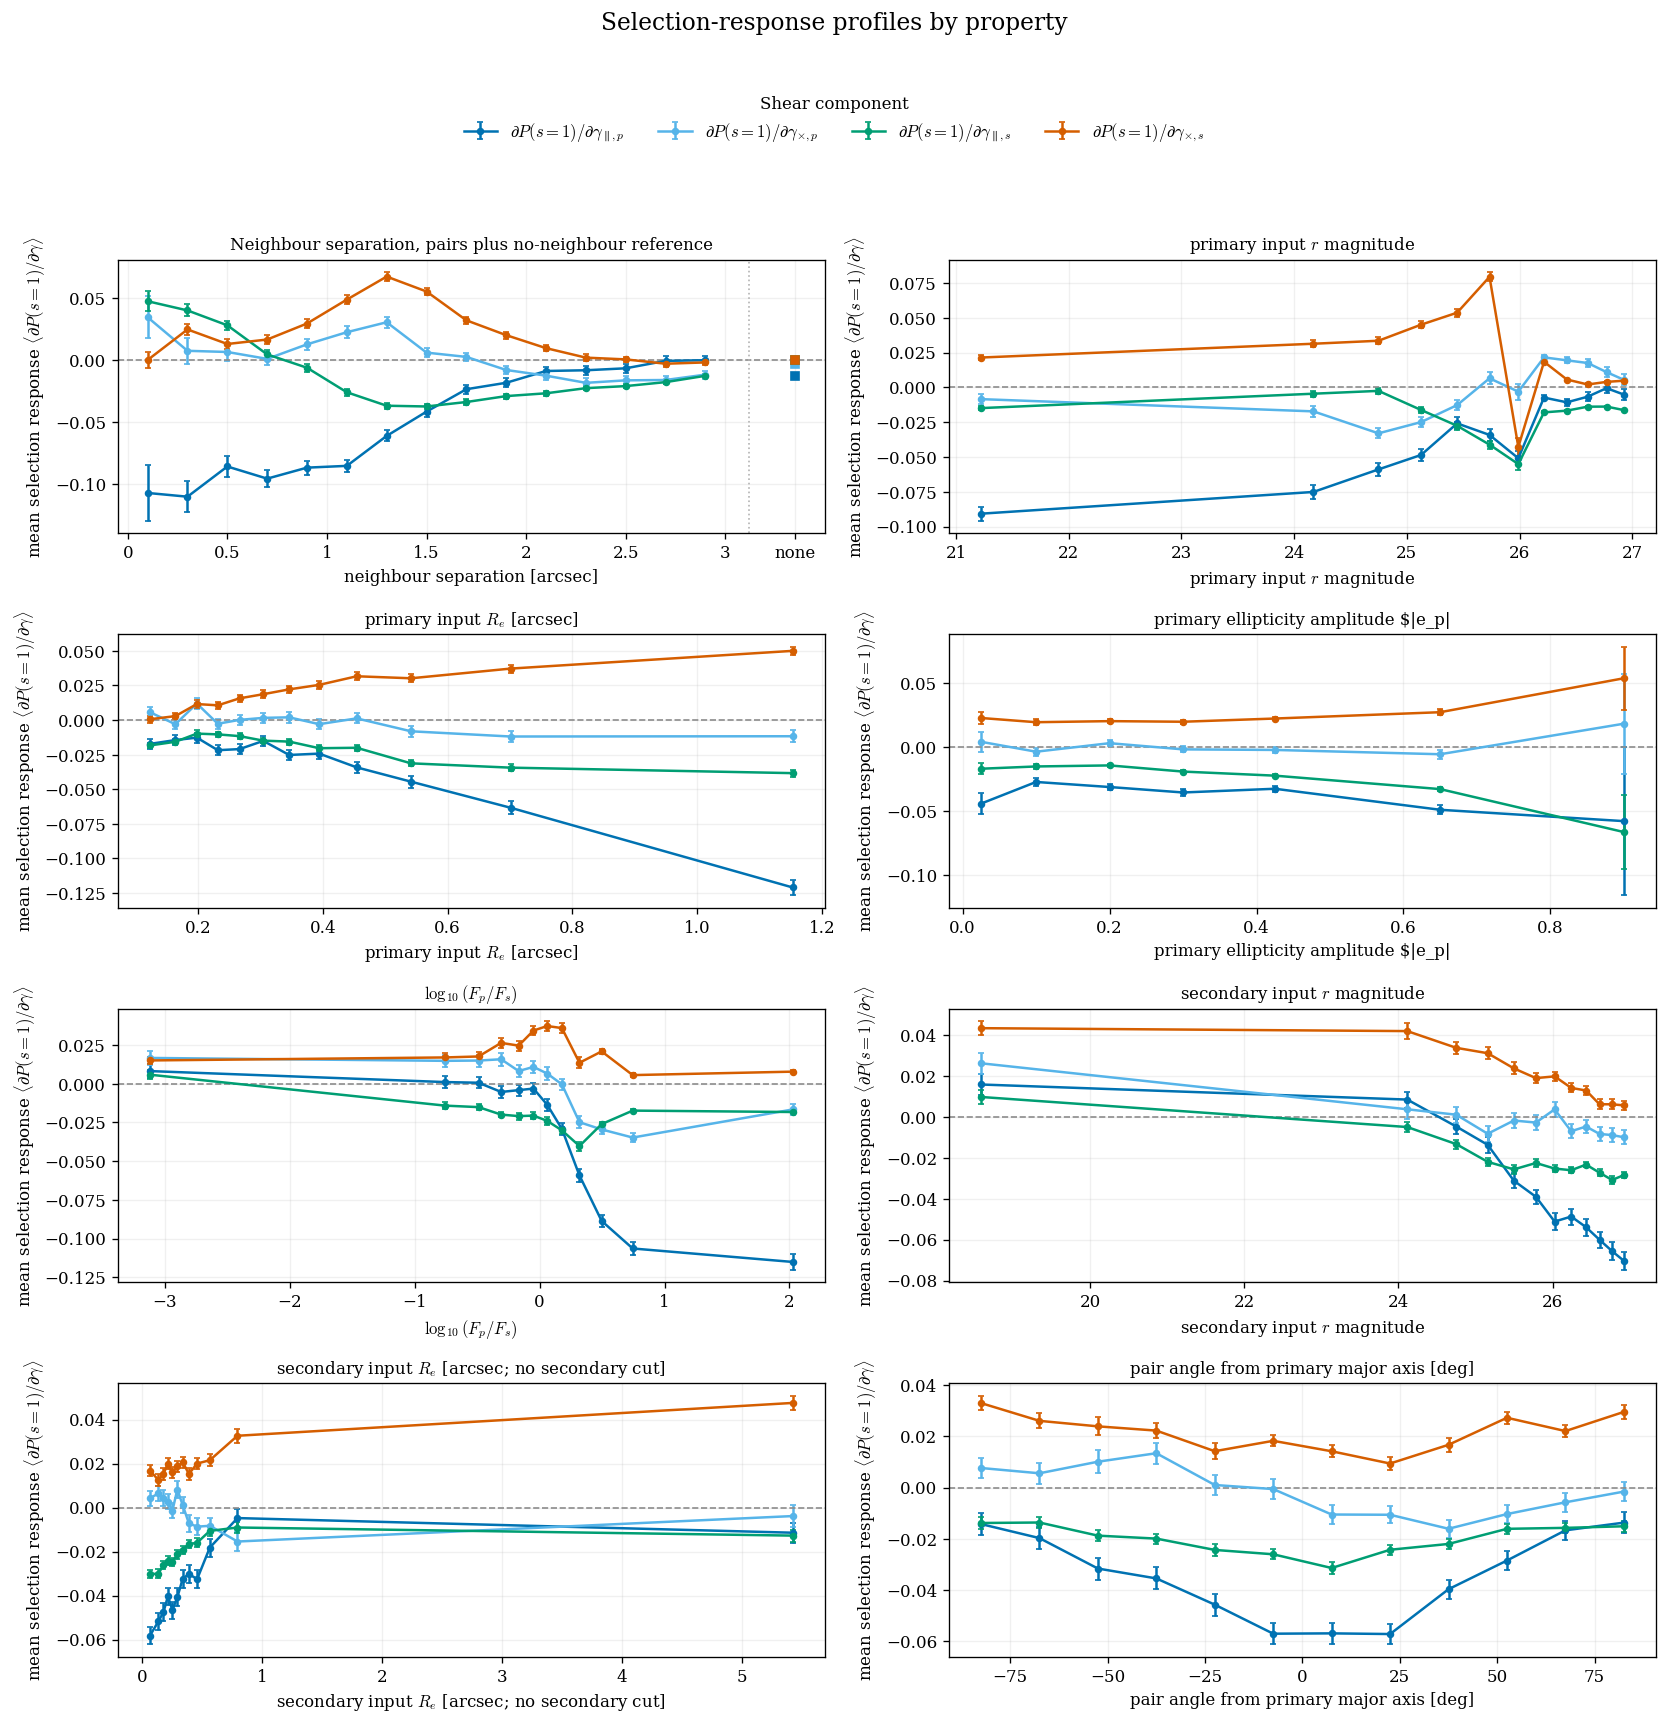

In [18]:
DISTANCE_GRADIENT_BIN_EDGES = np.linspace(0.0, 3.0, 16)
NO_NEIGHBOR_X = 3.35

rng = np.random.default_rng(RANDOM_STATE)
distance = eval_df["distance"].to_numpy(dtype=float)
neighbored = eval_df["neighbored"].astype(bool).to_numpy()
pair_mask = neighbored & np.isfinite(distance) & (distance >= 0.0) & (distance <= 3.0)
no_neighbor_mask = ~neighbored

pair_df = eval_df.loc[pair_mask].reset_index(drop=True)
no_neighbor_df = eval_df.loc[no_neighbor_mask].reset_index(drop=True)

if len(pair_df) > PAIR_DISTANCE_GRADIENT_ROWS:
    pair_df = pair_df.iloc[rng.choice(len(pair_df), PAIR_DISTANCE_GRADIENT_ROWS, replace=False)].reset_index(drop=True)
if len(no_neighbor_df) > NO_NEIGHBOR_GRADIENT_ROWS:
    no_neighbor_df = no_neighbor_df.iloc[rng.choice(len(no_neighbor_df), NO_NEIGHBOR_GRADIENT_ROWS, replace=False)].reset_index(drop=True)

distance_gradient_input = pd.concat(
    [
        pair_df.assign(_distance_subset="pair"),
        no_neighbor_df.assign(_distance_subset="no_neighbor"),
    ],
    ignore_index=True,
)

if {"pair_pframe_cos2", "pair_pframe_sin2"}.issubset(distance_gradient_input.columns):
    distance_gradient_input["pair_pframe_angle_deg"] = 0.5 * np.degrees(
        np.arctan2(
            distance_gradient_input["pair_pframe_sin2"].astype(float),
            distance_gradient_input["pair_pframe_cos2"].astype(float),
        )
    )

distance_gradient_features = [
    "gamma_pframe_parallel_p",
    "gamma_pframe_cross_p",
    "gamma_pframe_parallel_s_blend",
    "gamma_pframe_cross_s_blend",
]
distance_gradient_features = [name for name in distance_gradient_features if name in features]
print(f"Gradient features used: {distance_gradient_features}")
if not distance_gradient_features:
    raise RuntimeError("No primary-frame shear features are present in this checkpoint")

prob_distance_grad, distance_grad_df = bundle.probability_and_gradient(
    distance_gradient_input,
    gradient_features=distance_gradient_features,
    batch_size=GRADIENT_BATCH_SIZE,
)
distance_grad_aug = add_shear_aligned_gradients(distance_gradient_input, distance_grad_df)

context_cols = [
    "_distance_subset", "neighbored", "case", "shear_case", TARGET_COLUMN,
    "r_input_p", "Re_input_p", "sersic_n_input_p", "e_abs_p",
    "gamma_pframe_parallel_p", "gamma_pframe_cross_p",
    "distance", "pair_pframe_angle_deg", "pair_pframe_cos2", "pair_pframe_sin2",
    "r_input_s", "Re_input_s", "sersic_n_input_s", "flux_ratio",
    "e_pframe_parallel_s", "e_pframe_cross_s",
]
context_cols = [name for name in context_cols if name in distance_gradient_input.columns]
distance_gradient_work = pd.concat(
    [
        distance_gradient_input[context_cols].reset_index(drop=True),
        pd.Series(prob_distance_grad, name="prob_selection").reset_index(drop=True),
        distance_grad_aug.reset_index(drop=True),
    ],
    axis=1,
)

core_gradient_quantities = []
for suffix in ("p", "s"):
    parallel = f"dPsel_dgamma_parallel_{suffix}"
    cross = f"dPsel_dgamma_cross_{suffix}"
    core_gradient_quantities.extend([parallel, cross])
core_gradient_quantities = [name for name in core_gradient_quantities if name in distance_grad_aug.columns]

GRADIENT_LABELS = {
    "dPsel_dgamma_parallel_p": r"$\partial P(s=1)/\partial\gamma_{\parallel,p}$",
    "dPsel_dgamma_cross_p": r"$\partial P(s=1)/\partial\gamma_{\times,p}$",
    "dPsel_dgamma_parallel_s": r"$\partial P(s=1)/\partial\gamma_{\parallel,s}$",
    "dPsel_dgamma_cross_s": r"$\partial P(s=1)/\partial\gamma_{\times,s}$",
}
GRADIENT_COLORS = {
    "dPsel_dgamma_parallel_p": cbPalette[5],
    "dPsel_dgamma_cross_p": cbPalette[2],
    "dPsel_dgamma_parallel_s": cbPalette[3],
    "dPsel_dgamma_cross_s": cbPalette[6],
}


def finite_mean_sem(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {"n_finite": 0, "mean": np.nan, "sem": np.nan, "mean_abs": np.nan}
    std = np.std(values, ddof=1) if len(values) > 1 else np.nan
    return {
        "n_finite": int(len(values)),
        "mean": float(np.mean(values)),
        "sem": float(std / np.sqrt(len(values))) if len(values) > 1 else np.nan,
        "mean_abs": float(np.mean(np.abs(values))),
    }


def summarize_core_distance_gradients(frame, bins, quantities):
    rows = []
    distance = frame["distance"].to_numpy(dtype=float)
    is_pair = frame["_distance_subset"].to_numpy() == "pair"
    for bin_index, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
        upper = distance <= hi if bin_index == len(bins) - 2 else distance < hi
        mask = is_pair & np.isfinite(distance) & (distance >= lo) & upper
        row = {
            "subset": "pair_distance_bin",
            "label": f"{lo:.1f}-{hi:.1f}",
            "x": float(0.5 * (lo + hi)),
            "distance_min": float(lo),
            "distance_max": float(hi),
            "rows_total": int(mask.sum()),
        }
        for quantity in quantities:
            stats = finite_mean_sem(frame.loc[mask, quantity])
            for key, value in stats.items():
                row[f"{quantity}_{key}"] = value
        rows.append(row)

    mask = frame["_distance_subset"].to_numpy() == "no_neighbor"
    row = {
        "subset": "no_neighbor",
        "label": "no neighbour",
        "x": NO_NEIGHBOR_X,
        "distance_min": np.nan,
        "distance_max": np.nan,
        "rows_total": int(mask.sum()),
    }
    for quantity in quantities:
        stats = finite_mean_sem(frame.loc[mask, quantity])
        for key, value in stats.items():
            row[f"{quantity}_{key}"] = value
    rows.append(row)
    return pd.DataFrame(rows)


def quantile_edges(values, n_bins=12, min_unique=4):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return None
    edges = np.nanquantile(values, np.linspace(0.0, 1.0, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < min_unique:
        return None
    edges[0] = np.nextafter(edges[0], -np.inf)
    edges[-1] = np.nextafter(edges[-1], np.inf)
    return edges


def summarize_binned_property_gradients(frame, specs, quantities):
    rows = []
    pair_mask = frame["_distance_subset"].to_numpy() == "pair"
    for spec in specs:
        column = spec["column"]
        if column not in frame.columns:
            continue
        base_mask = pair_mask.copy()
        if spec.get("finite_distance", False):
            base_mask &= np.isfinite(frame["distance"].to_numpy(dtype=float))
        values = frame[column].to_numpy(dtype=float)
        if "bins" in spec:
            bins = np.asarray(spec["bins"], dtype=float)
        else:
            bins = quantile_edges(values[base_mask], n_bins=spec.get("n_bins", 12))
        if bins is None or len(bins) < 2:
            continue
        for bin_index, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
            upper = values <= hi if bin_index == len(bins) - 2 else values < hi
            mask = base_mask & np.isfinite(values) & (values >= lo) & upper
            row = {
                "property": column,
                "property_label": spec["label"],
                "x_label": spec.get("x_label", spec["label"]),
                "bin_label": f"{lo:.3g}-{hi:.3g}",
                "x": float(0.5 * (lo + hi)),
                "bin_min": float(lo),
                "bin_max": float(hi),
                "rows_total": int(mask.sum()),
            }
            for quantity in quantities:
                stats = finite_mean_sem(frame.loc[mask, quantity])
                for key, value in stats.items():
                    row[f"{quantity}_{key}"] = value
            rows.append(row)
    return pd.DataFrame(rows)


core_distance_gradient_summary = summarize_core_distance_gradients(
    distance_gradient_work,
    DISTANCE_GRADIENT_BIN_EDGES,
    core_gradient_quantities,
)
display(core_distance_gradient_summary)

IMPORTANT_GRADIENT_PROPERTY_SPECS = [
    {"column": "r_input_p", "label": r"primary input $r$ magnitude", "n_bins": 12},
    {"column": "Re_input_p", "label": r"primary input $R_e$ [arcsec]", "n_bins": 12},
    {"column": "e_abs_p", "label": r"primary ellipticity amplitude $|e_p|", "bins": [0.0, 0.05, 0.15, 0.25, 0.35, 0.5, 0.8, 1.0]},
    {"column": "distance", "label": r"neighbour separation [arcsec]", "bins": DISTANCE_GRADIENT_BIN_EDGES, "finite_distance": True},
    {"column": "flux_ratio", "label": r"$\log_{10}(F_p/F_s)$", "n_bins": 12},
    {"column": "r_input_s", "label": r"secondary input $r$ magnitude", "n_bins": 12},
    {"column": "Re_input_s", "label": r"secondary input $R_e$ [arcsec; no secondary cut]", "n_bins": 12},
    {"column": "pair_pframe_angle_deg", "label": r"pair angle from primary major axis [deg]", "bins": np.linspace(-90, 90, 13)},
]

important_property_gradient_summary = summarize_binned_property_gradients(
    distance_gradient_work,
    IMPORTANT_GRADIENT_PROPERTY_SPECS,
    core_gradient_quantities,
)
if len(important_property_gradient_summary) == 0:
    print("No important-property gradient summaries could be built from this sample.")
else:
    display(
        important_property_gradient_summary[
            ["property", "bin_label", "rows_total"]
            + [f"{quantity}_mean" for quantity in core_gradient_quantities]
            + [f"{quantity}_sem" for quantity in core_gradient_quantities]
        ]
    )

    property_overview_rows = []
    for (prop, label), grp in important_property_gradient_summary.groupby(["property", "property_label"], sort=False):
        row = {"property": prop, "property_label": label, "rows_total": int(grp["rows_total"].sum())}
        for quantity in core_gradient_quantities:
            means = grp[f"{quantity}_mean"].to_numpy(dtype=float)
            row[f"{quantity}_mean_range"] = float(np.nanmax(means) - np.nanmin(means)) if np.any(np.isfinite(means)) else np.nan
            row[f"{quantity}_max_abs_mean"] = float(np.nanmax(np.abs(means))) if np.any(np.isfinite(means)) else np.nan
        property_overview_rows.append(row)
    important_property_gradient_overview = pd.DataFrame(property_overview_rows)
    display(important_property_gradient_overview)


def plot_four_component_panel(ax, summary, x_label, title, include_no_neighbor=False):
    if include_no_neighbor:
        pair_summary = summary.query("subset == 'pair_distance_bin' and rows_total > 0")
    else:
        pair_summary = summary.query("rows_total > 0")
    for quantity in core_gradient_quantities:
        mean_col = f"{quantity}_mean"
        sem_col = f"{quantity}_sem"
        if mean_col not in pair_summary.columns:
            continue
        ax.errorbar(
            pair_summary["x"],
            pair_summary[mean_col],
            yerr=pair_summary[sem_col],
            marker="o",
            linewidth=1.5,
            markersize=3.5,
            capsize=2,
            color=GRADIENT_COLORS.get(quantity),
            label=GRADIENT_LABELS.get(quantity, quantity),
        )
        if include_no_neighbor:
            none_summary = summary.query("subset == 'no_neighbor' and rows_total > 0")
            if len(none_summary):
                ax.errorbar(
                    none_summary["x"],
                    none_summary[mean_col],
                    yerr=none_summary[sem_col],
                    marker="s",
                    linestyle="none",
                    markersize=4.5,
                    capsize=2,
                    color=GRADIENT_COLORS.get(quantity),
                )
    ax.axhline(0.0, color="0.55", linestyle="--", linewidth=1)
    ax.grid(alpha=0.18)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel(r"mean selection response $\langle \partial P(s=1)/\partial\gamma \rangle$")


if len(important_property_gradient_summary):
    panel_specs = [
        {
            "kind": "distance",
            "summary": core_distance_gradient_summary,
            "title": "Neighbour separation, pairs plus no-neighbour reference",
            "x_label": r"neighbour separation [arcsec]",
        }
    ]
    for spec in IMPORTANT_GRADIENT_PROPERTY_SPECS:
        if spec["column"] == "distance":
            continue
        if spec["column"] not in set(important_property_gradient_summary["property"]):
            continue
        panel_specs.append(
            {
                "kind": "property",
                "property": spec["column"],
                "title": spec["label"],
                "x_label": spec["label"],
            }
        )

    ncols = 2
    nrows = int(np.ceil(len(panel_specs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), squeeze=False)
    axes = axes.ravel()
    for panel_index, panel in enumerate(panel_specs):
        ax = axes[panel_index]
        if panel["kind"] == "distance":
            plot_four_component_panel(
                ax,
                panel["summary"],
                panel["x_label"],
                panel["title"],
                include_no_neighbor=True,
            )
            xticks = list(np.arange(0.0, 3.01, 0.5)) + [NO_NEIGHBOR_X]
            xticklabels = [f"{x:g}" for x in np.arange(0.0, 3.01, 0.5)] + ["none"]
            ax.set_xlim(-0.05, 3.5)
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels)
            ax.axvline(3.12, color="0.7", linestyle=":", linewidth=1)
        else:
            prop_summary = important_property_gradient_summary[important_property_gradient_summary["property"].eq(panel["property"])]
            plot_four_component_panel(
                ax,
                prop_summary,
                panel["x_label"],
                panel["title"],
                include_no_neighbor=False,
            )
    for ax in axes[len(panel_specs):]:
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.955),
            ncol=4,
            frameon=False,
            fontsize=10,
            title="Shear component",
            title_fontsize=10,
        )
    fig.suptitle("Selection-response profiles by property", y=0.995, fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.90))

print(
    "Each panel shows the binned mean response dP(s=1)/dgamma for the four primary-frame shear components. "
    "Error bars are standard errors on the binned mean. Only the distance panel includes the separate no-neighbour reference."
)

## 13. Distance Gradients Split By Primary |e|

This stress test checks the primary-frame caveat directly. The primary-major-axis frame is physically weakest when the primary is nearly round, so the distance-gradient trends should be compared across `e_abs_p` bins. If the low-`e_abs_p` curves are unstable, sign-flipped, or dominate the average despite being a small population, the frame choice is likely injecting noise into the response estimate.

In [ ]:
required_objects = [
    "distance_gradient_work",
    "core_gradient_quantities",
    "DISTANCE_GRADIENT_BIN_EDGES",
    "NO_NEIGHBOR_X",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f"Run the core distance-gradient cell first; missing {missing_objects}")
if "e_abs_p" not in distance_gradient_work.columns:
    raise RuntimeError("The distance-gradient work table does not contain e_abs_p")

E_ABS_SPLIT_EDGES = np.array([0.0, 0.05, 0.15, 0.35, np.inf])
E_ABS_SPLIT_LABELS = [
    "round |e|<0.05",
    "low 0.05<=|e|<0.15",
    "mid 0.15<=|e|<0.35",
    "high |e|>=0.35",
]

e_split_work = distance_gradient_work.copy()
e_split_work["e_abs_bin"] = pd.cut(
    e_split_work["e_abs_p"].astype(float),
    bins=E_ABS_SPLIT_EDGES,
    labels=E_ABS_SPLIT_LABELS,
    include_lowest=True,
    right=False,
)

def summarize_distance_gradients_by_e(frame, bins, quantities):
    rows = []
    distance = frame["distance"].to_numpy(dtype=float)
    subset = frame["_distance_subset"].astype(str).to_numpy()
    e_bin_values = frame["e_abs_bin"].astype(object)

    for e_label in E_ABS_SPLIT_LABELS:
        e_mask = e_bin_values.to_numpy() == e_label
        for bin_index, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
            upper = distance <= hi if bin_index == len(bins) - 2 else distance < hi
            mask = e_mask & (subset == "pair") & np.isfinite(distance) & (distance >= lo) & upper
            row = {
                "subset": "pair_distance_bin",
                "e_abs_bin": e_label,
                "label": f"{lo:.1f}-{hi:.1f}",
                "x": float(0.5 * (lo + hi)),
                "distance_min": float(lo),
                "distance_max": float(hi),
                "rows_total": int(mask.sum()),
            }
            for quantity in quantities:
                stats = finite_mean_sem(frame.loc[mask, quantity])
                for key, value in stats.items():
                    row[f"{quantity}_{key}"] = value
            rows.append(row)

        mask = e_mask & (subset == "no_neighbor")
        row = {
            "subset": "no_neighbor",
            "e_abs_bin": e_label,
            "label": "no neighbour",
            "x": NO_NEIGHBOR_X,
            "distance_min": np.nan,
            "distance_max": np.nan,
            "rows_total": int(mask.sum()),
        }
        for quantity in quantities:
            stats = finite_mean_sem(frame.loc[mask, quantity])
            for key, value in stats.items():
                row[f"{quantity}_{key}"] = value
        rows.append(row)
    return pd.DataFrame(rows)


e_abs_distance_gradient_summary = summarize_distance_gradients_by_e(
    e_split_work,
    DISTANCE_GRADIENT_BIN_EDGES,
    core_gradient_quantities,
)

e_abs_rows = (
    e_abs_distance_gradient_summary
    .groupby(["subset", "e_abs_bin"], observed=False, as_index=False)["rows_total"]
    .sum()
)
display(e_abs_rows)

summary_columns = ["subset", "e_abs_bin", "label", "x", "rows_total"]
for quantity in core_gradient_quantities:
    summary_columns.extend([f"{quantity}_mean", f"{quantity}_sem", f"{quantity}_mean_abs"])
display(e_abs_distance_gradient_summary[summary_columns])

ncols = 2
nrows = int(np.ceil(len(core_gradient_quantities) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.0 * nrows), sharex=True, squeeze=False)
axes = axes.ravel()

for idx, quantity in enumerate(core_gradient_quantities):
    ax = axes[idx]
    for group_index, e_label in enumerate(E_ABS_SPLIT_LABELS):
        color = cbPalette[(group_index + 1) % len(cbPalette)]
        pair_summary = e_abs_distance_gradient_summary[
            (e_abs_distance_gradient_summary["subset"] == "pair_distance_bin")
            & (e_abs_distance_gradient_summary["e_abs_bin"] == e_label)
            & (e_abs_distance_gradient_summary["rows_total"] > 0)
        ]
        if len(pair_summary):
            ax.errorbar(
                pair_summary["x"],
                pair_summary[f"{quantity}_mean"],
                yerr=pair_summary[f"{quantity}_sem"],
                marker="o",
                linewidth=1.5,
                markersize=3.5,
                capsize=2,
                color=color,
                label=e_label,
            )

        no_neighbor_summary = e_abs_distance_gradient_summary[
            (e_abs_distance_gradient_summary["subset"] == "no_neighbor")
            & (e_abs_distance_gradient_summary["e_abs_bin"] == e_label)
            & (e_abs_distance_gradient_summary["rows_total"] > 0)
        ]
        if len(no_neighbor_summary):
            ax.errorbar(
                no_neighbor_summary["x"],
                no_neighbor_summary[f"{quantity}_mean"],
                yerr=no_neighbor_summary[f"{quantity}_sem"],
                marker="s",
                markersize=5,
                capsize=3,
                color=color,
            )

    ax.axhline(0.0, color="0.5", linestyle="--", linewidth=1)
    ax.axvline(3.12, color="0.7", linestyle=":", linewidth=1)
    ax.set_title(quantity)
    ax.set_ylabel("mean autograd gradient")
    ax.grid(alpha=0.2)
    if idx == 0:
        ax.legend(frameon=False, fontsize=8)
for ax in axes[len(core_gradient_quantities):]:
    ax.axis("off")

xticks = list(np.arange(0.0, 3.01, 0.5)) + [NO_NEIGHBOR_X]
xticklabels = [f"{x:g}" for x in np.arange(0.0, 3.01, 0.5)] + ["none"]
for ax in axes:
    ax.set_xlim(-0.05, 3.5)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
for ax in axes[max(0, len(axes) - ncols):]:
    ax.set_xlabel("neighbour distance [arcsec]")
plt.tight_layout()

print(
    "Read this as a frame-stability test. The round-primary bin is expected to have larger SEM and weaker physical interpretation; "
    "the key question is whether it qualitatively disagrees with the better-defined mid/high-|e| bins."
)